# 04 — Age Group Analysis
How vaccination rates differ across age brackets.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

OUT = os.path.join("..", "outputs")
os.makedirs(OUT, exist_ok=True)

In [2]:
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/vaccinations/vaccinations-by-age-group.csv"
print("Fetching age group data...")
df = pd.read_csv(url)
print(f"Raw shape: {df.shape}")
df.head()

Fetching age group data...


Raw shape: (73291, 6)


,location,date,age_group,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,people_with_booster_per_hundred
0,Argentina,2020-01-01,100+,0.0,0.0,0.0
1,Argentina,2020-01-01,12-17,0.0,0.0,0.0
2,Argentina,2020-01-01,18-29,0.0,0.0,0.0
3,Argentina,2020-01-01,3-11,0.0,0.0,0.0
4,Argentina,2020-01-01,30-39,0.0,0.0,0.0


## 1. Clean up

In [3]:
df = df.dropna(subset=["people_fully_vaccinated_per_hundred", "age_group"])
print(f"After cleaning: {df.shape}")
print(f"Age groups: {sorted(df['age_group'].unique())}")

After cleaning: (71642, 6)
Age groups: ['0-15', '0-17', '0-19', '0-4', '0-5', '10-14', '100+', '12-15', '12-17', '12-64', '15-17', '16-17', '16-19', '16-69', '18-24', '18-29', '18-69', '20-29', '25-34', '25-49', '3-11', '30-39', '35-44', '40-49', '45-54', '5-11', '5-9', '50-54', '50-59', '55-59', '55-64', '60-64', '60-69', '65+', '65-69', '65-74', '70-74', '70-79', '75+', '75-79', '80+', '80-89', '90+', '90-99']


## 2. Boxplot — vaccination rate by age group

C:\Users\Aryan\AppData\Local\Temp\ipykernel_13524\1824764172.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="age_group", y="people_fully_vaccinated_per_hundred",


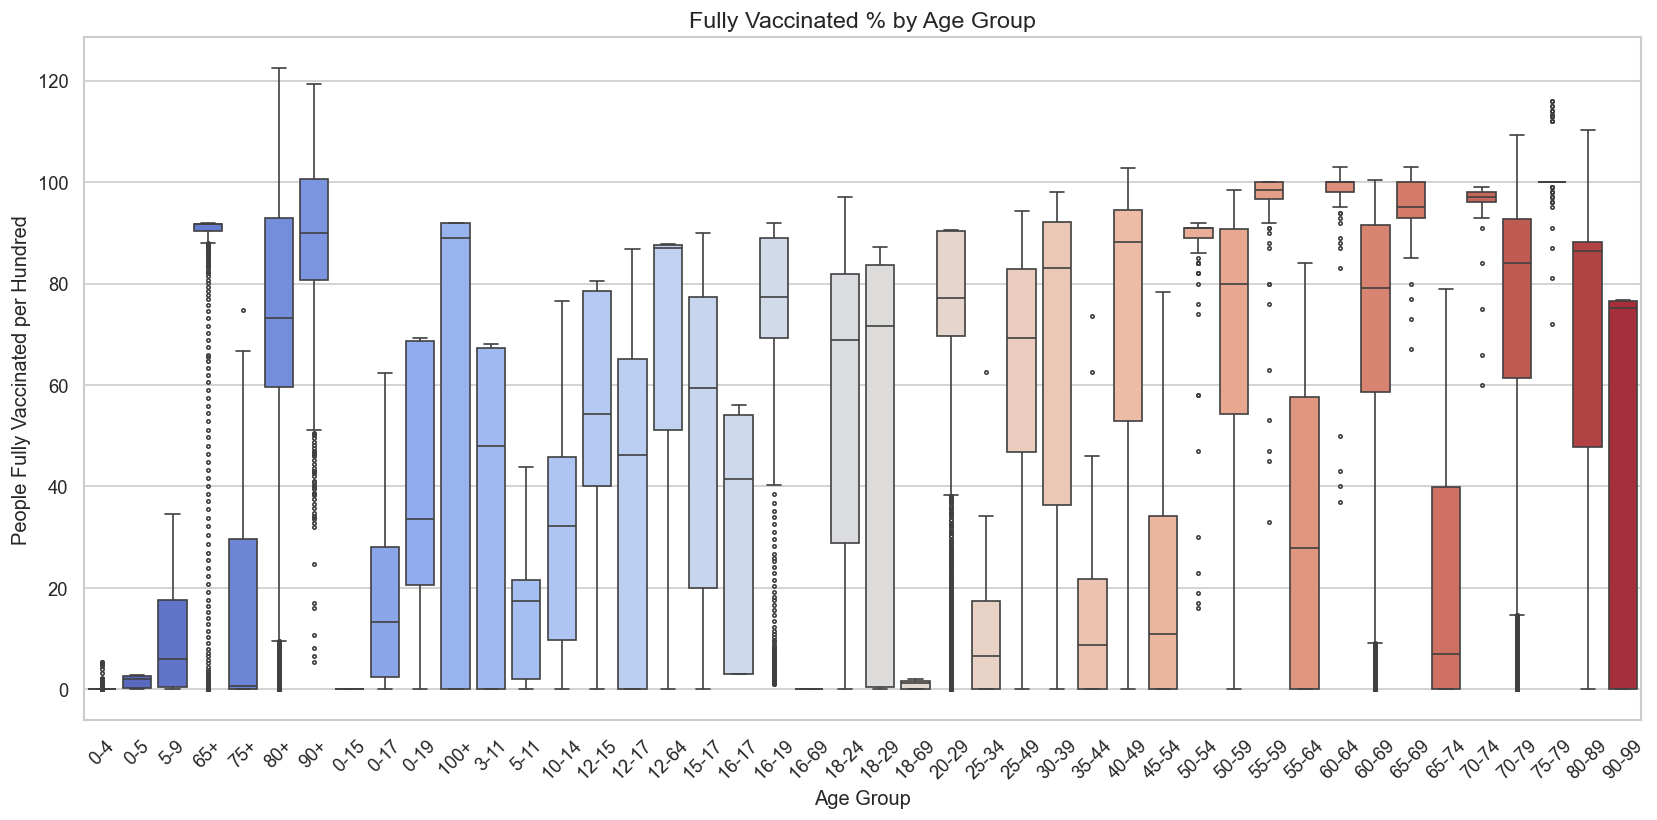

In [4]:
# sort age groups so they read naturally
age_order = sorted(df["age_group"].unique(), key=lambda x: (len(x), x))

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=df, x="age_group", y="people_fully_vaccinated_per_hundred",
            order=age_order, palette="coolwarm", ax=ax, fliersize=2)
ax.set_title("Fully Vaccinated % by Age Group", fontsize=14)
ax.set_xlabel("Age Group")
ax.set_ylabel("People Fully Vaccinated per Hundred")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "age_group_boxplot.png"))
plt.show()

## 3. KDE overlay — all age groups

C:\Users\Aryan\AppData\Local\Temp\ipykernel_13524\2112612858.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset, label=grp, color=palette[i], ax=ax, linewidth=1.5, fill=False)
C:\Users\Aryan\AppData\Local\Temp\ipykernel_13524\2112612858.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset, label=grp, color=palette[i], ax=ax, linewidth=1.5, fill=False)


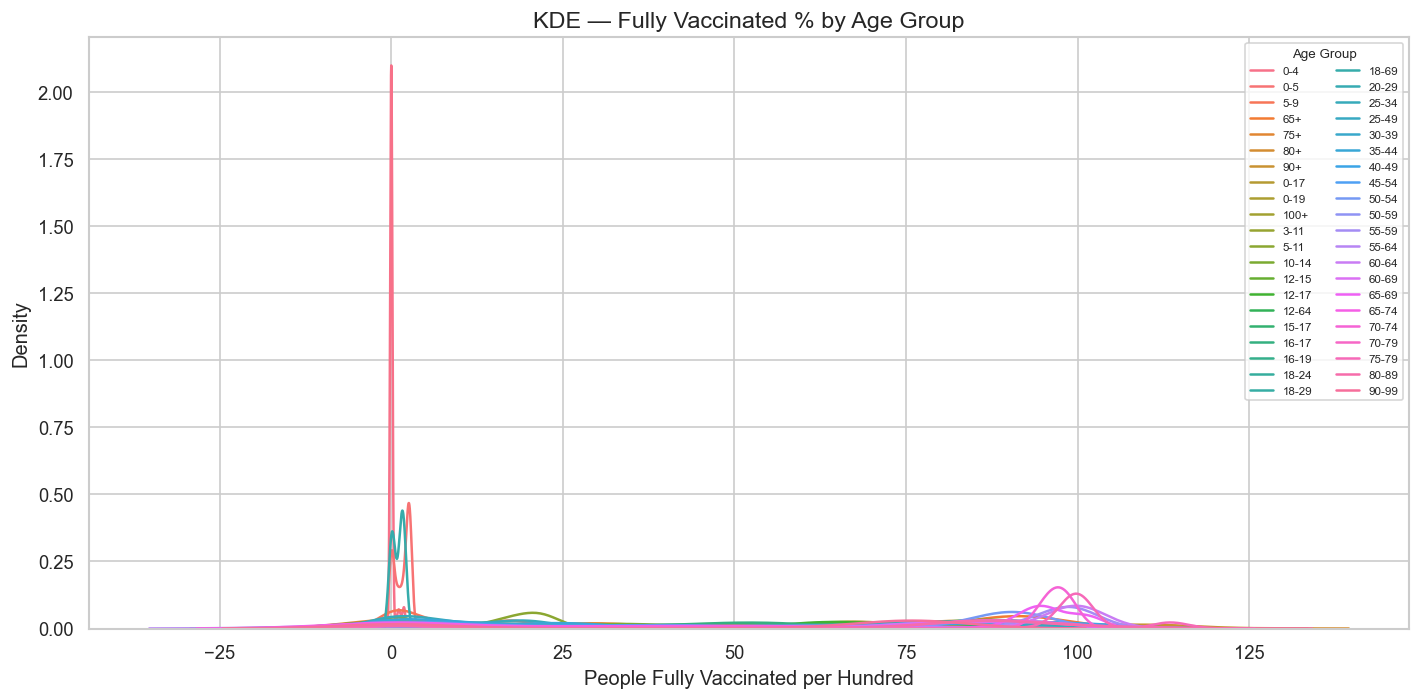

In [5]:
palette = sns.color_palette("husl", len(age_order))

fig, ax = plt.subplots(figsize=(12, 6))
for i, grp in enumerate(age_order):
    subset = df[df["age_group"] == grp]["people_fully_vaccinated_per_hundred"]
    sns.kdeplot(subset, label=grp, color=palette[i], ax=ax, linewidth=1.5, fill=False)

ax.set_title("KDE — Fully Vaccinated % by Age Group", fontsize=14)
ax.set_xlabel("People Fully Vaccinated per Hundred")
ax.legend(fontsize=7, ncol=2, title="Age Group", title_fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "age_group_kde.png"))
plt.show()

## 4. Histograms — one subplot per age group

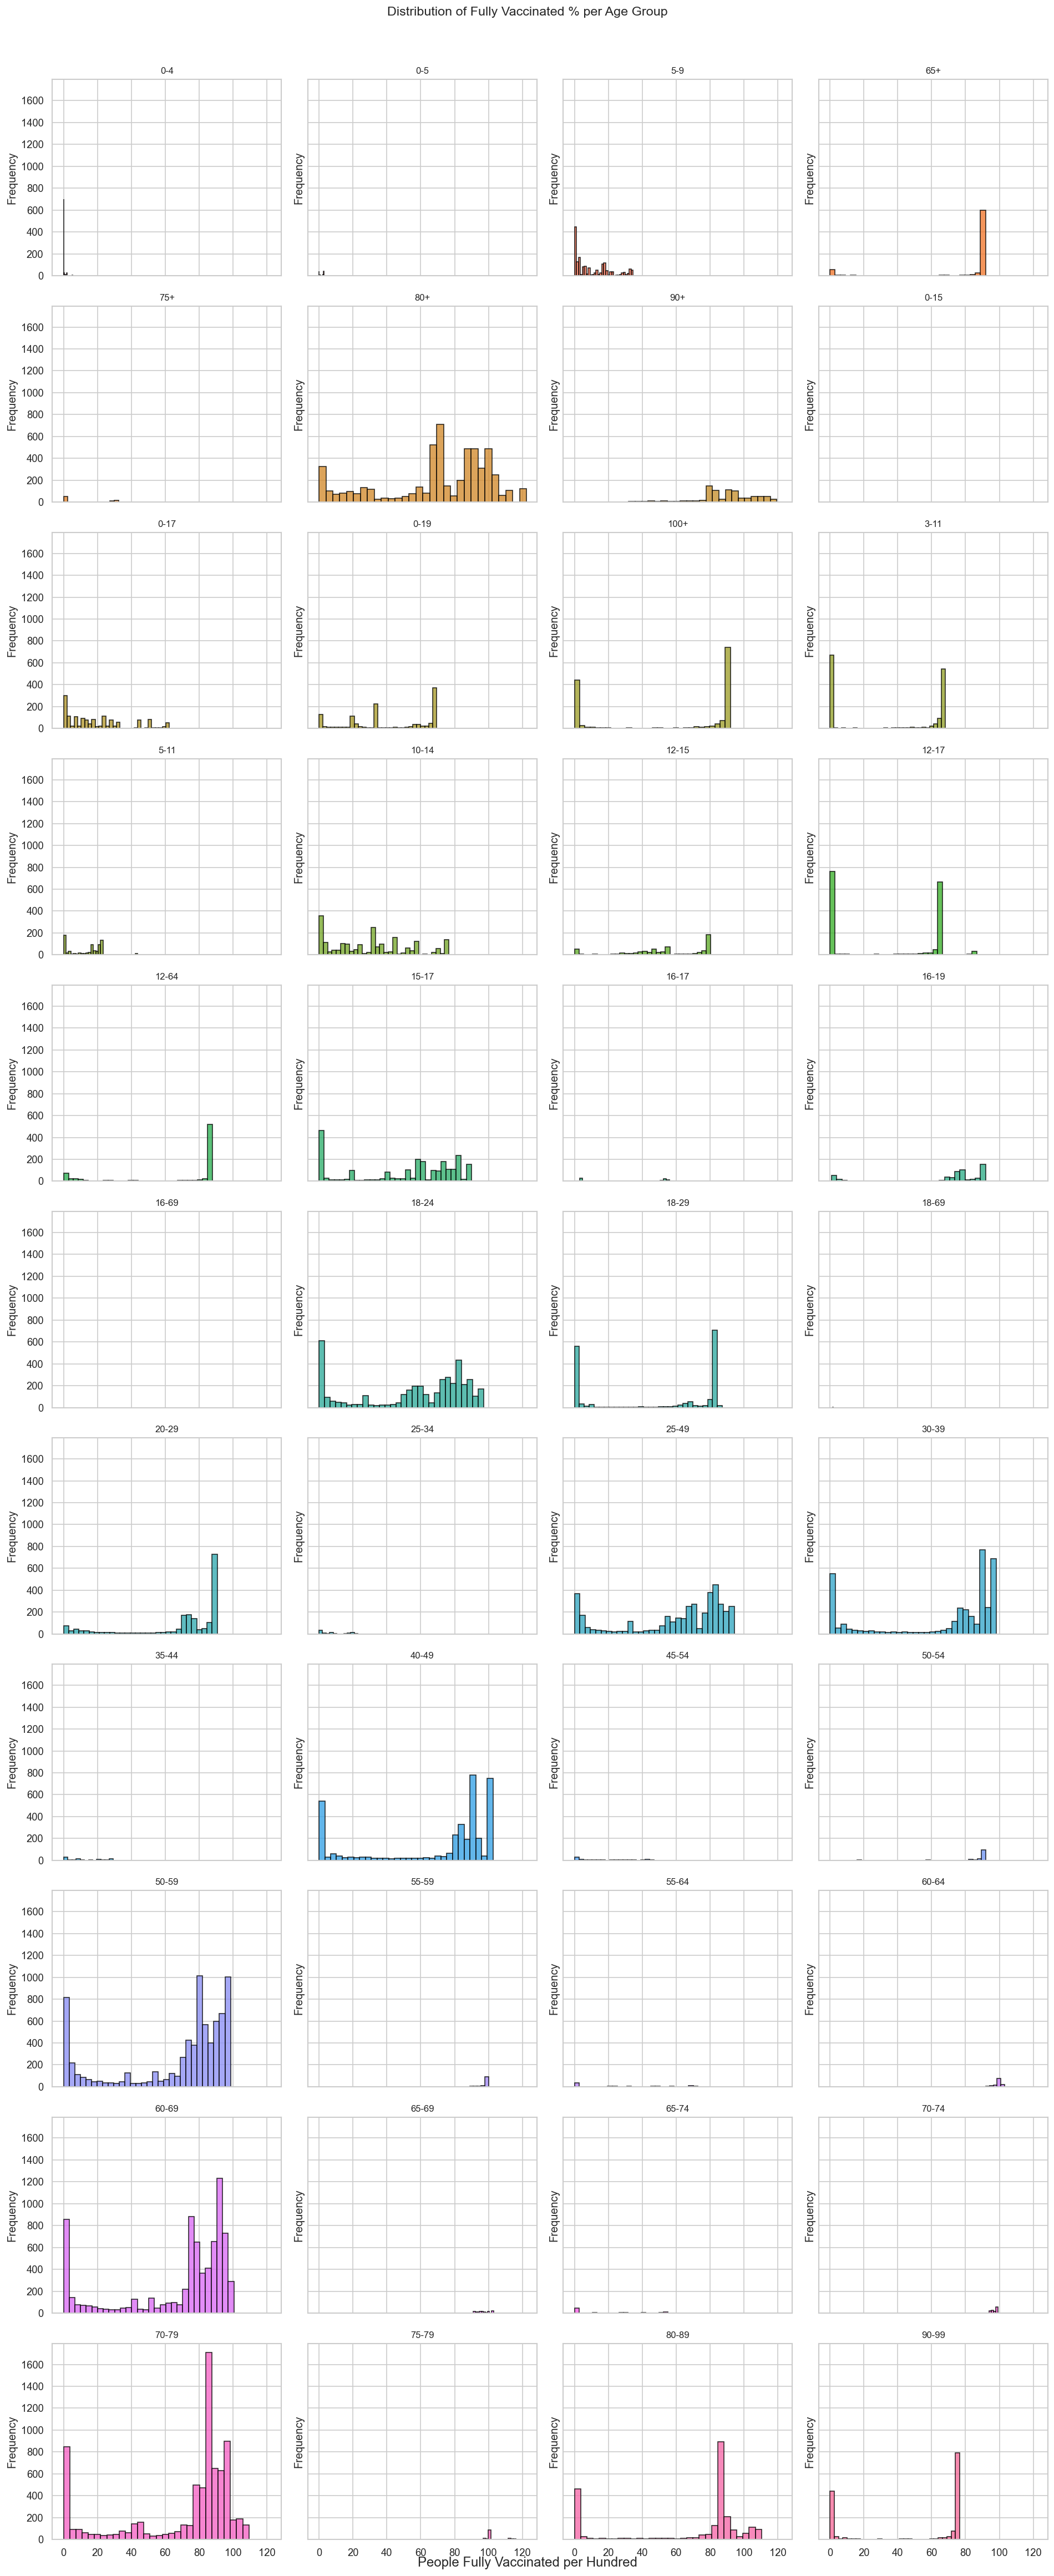

In [6]:
n = len(age_order)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 3.5 * rows), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, grp in enumerate(age_order):
    ax = axes_flat[i]
    subset = df[df["age_group"] == grp]["people_fully_vaccinated_per_hundred"]
    ax.hist(subset, bins=30, color=palette[i], edgecolor="black", alpha=0.8)
    ax.set_title(grp, fontsize=10)
    ax.set_ylabel("Frequency")

# hide empty subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Distribution of Fully Vaccinated % per Age Group", fontsize=14, y=1.01)
fig.supxlabel("People Fully Vaccinated per Hundred")
fig.tight_layout()
fig.savefig(os.path.join(OUT, "age_group_histograms.png"), bbox_inches="tight")
plt.show()

## 5. Which age group has the lowest median?

In [7]:
medians = df.groupby("age_group")["people_fully_vaccinated_per_hundred"].median().sort_values()

print("Median fully vaccinated % by age group:")
for grp, val in medians.items():
    marker = " ← LOWEST" if grp == medians.index[0] else ""
    print(f"  {grp:20s}  {val:6.2f}%{marker}")

Median fully vaccinated % by age group:
  0-15                    0.00% ← LOWEST
  0-4                     0.00%
  16-69                   0.00%
  75+                     0.71%
  18-69                   1.34%
  0-5                     1.95%
  5-9                     5.91%
  25-34                   6.57%
  65-74                   6.88%
  35-44                   8.80%
  45-54                  10.91%
  0-17                   13.36%
  5-11                   17.38%
  55-64                  27.85%
  10-14                  32.15%
  0-19                   33.51%
  16-17                  41.50%
  12-17                  46.18%
  3-11                   47.88%
  12-15                  54.20%
  15-17                  59.44%
  18-24                  68.87%
  25-49                  69.31%
  18-29                  71.72%
  80+                    73.20%
  90-99                  75.10%
  20-29                  77.11%
  16-19                  77.25%
  60-69                  79.08%
  50-59                